In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("Cleaned_Customer_Data.csv")

In [4]:
target = "Total Revenue"

drop_columns = [
    "Customer ID",
    "Total Charges",
    "Total Long Distance Charges",
    "Total Extra Data Charges",
    "Total Refunds",
    "Churn Category",
    "Churn Reason"
]

drop_columns = [
    col for col in drop_columns
    if col in df.columns
]

X = df.drop(columns=drop_columns + [target])
y = df[target]

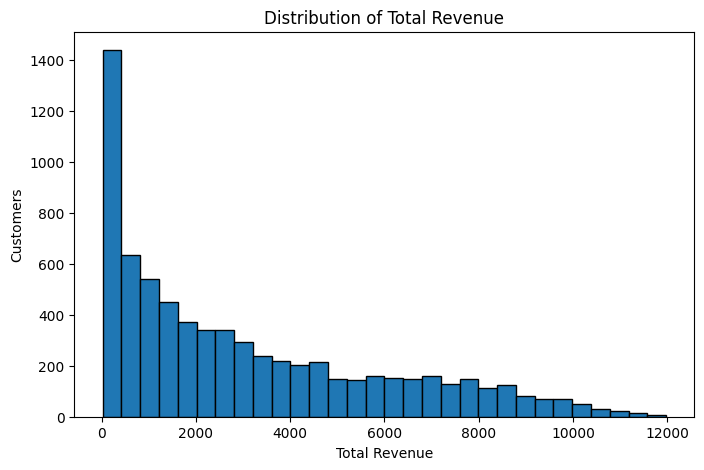

In [5]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Total Revenue"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Total Revenue")
plt.ylabel("Customers")
plt.title("Distribution of Total Revenue")

plt.show()

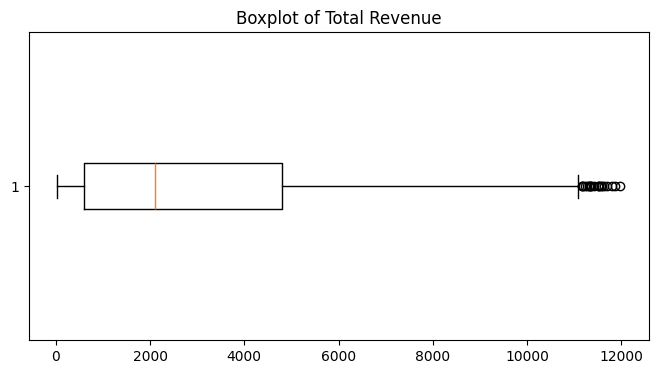

In [6]:
plt.figure(figsize=(8,4))

plt.boxplot(
    df["Total Revenue"],
    vert=False
)

plt.title("Boxplot of Total Revenue")

plt.show()

In [7]:
print("Skewness:", df["Total Revenue"].skew())

Skewness: 0.9194102679721669


In [8]:
numeric_df = df.select_dtypes(include=np.number)

revenue_corr = (
    numeric_df
    .corr()["Total Revenue"]
    .sort_values(ascending=False)
)

display(revenue_corr)

Total Revenue                        1.000000
Total Charges                        0.972212
Tenure in Months                     0.853146
Total Long Distance Charges          0.778559
Monthly Charge                       0.563249
Number of Referrals                  0.261853
Avg Monthly Long Distance Charges    0.232291
Avg Monthly GB Download              0.180726
Total Extra Data Charges             0.122496
Age                                  0.048265
Number of Dependents                 0.038038
Total Refunds                        0.036984
Zip Code                             0.002944
Longitude                            0.001062
Latitude                             0.000082
Name: Total Revenue, dtype: float64

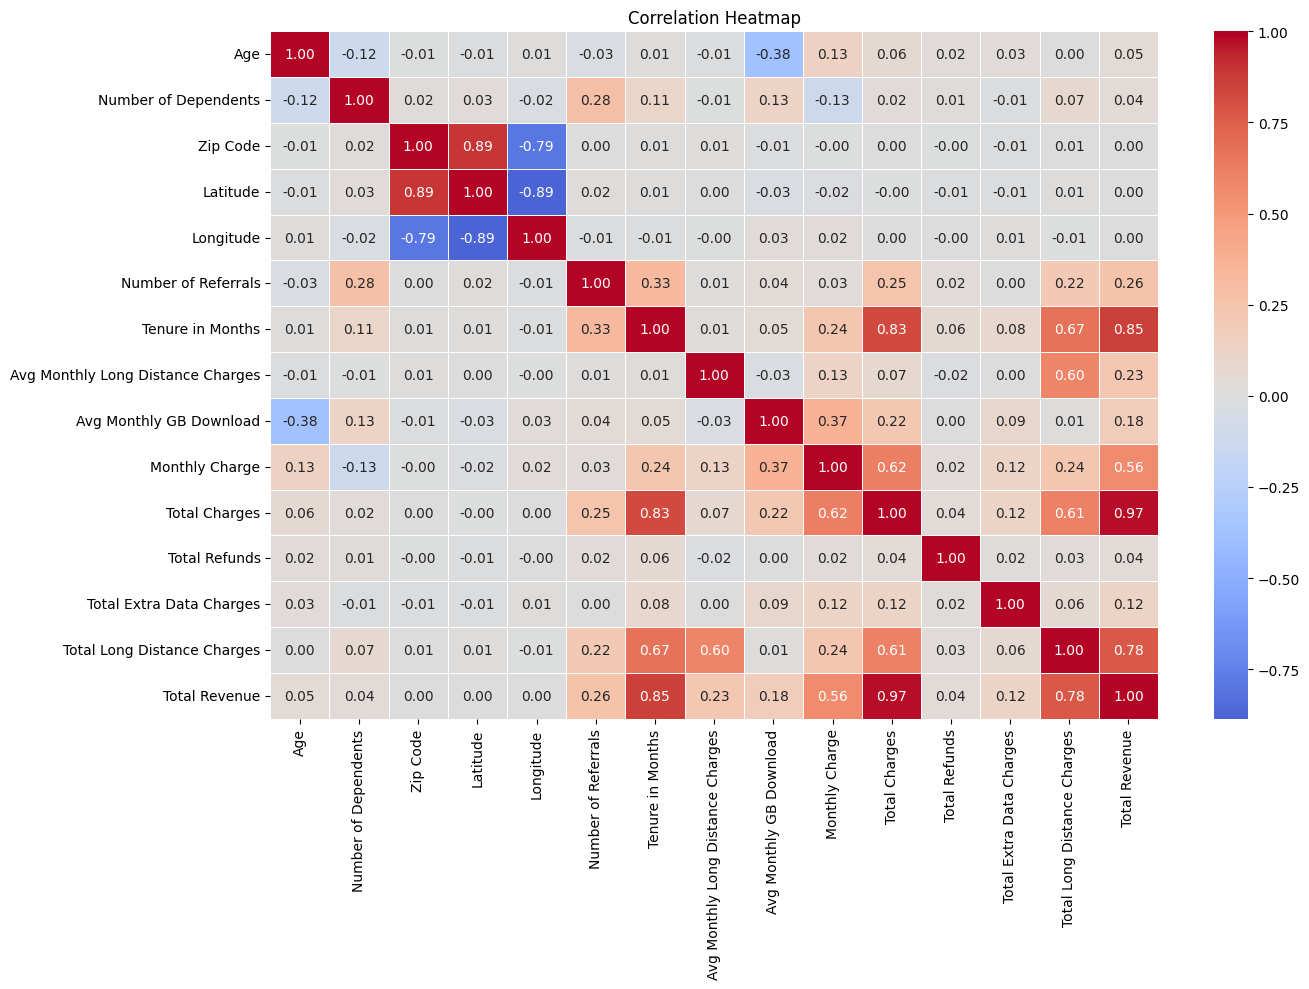

In [9]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [10]:
service_columns = [

    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data"

]

service_columns = [
    col
    for col in service_columns
    if col in X.columns
]

X["Number of Services"] = (
    X[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

In [16]:
numeric_features = (
    X_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(include=["object", "category", "string"])
    .columns
    .tolist()
)

In [17]:
numeric_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    )

])

categorical_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )

])

preprocessor = ColumnTransformer([

    (
        "num",
        numeric_pipeline,
        numeric_features
    ),

    (
        "cat",
        categorical_pipeline,
        categorical_features
    )

])

In [18]:
rf_model = Pipeline([

    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        RandomForestRegressor(

            n_estimators=200,
            random_state=42,
            n_jobs=-1

        )
    )

])

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [19]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_mse = mean_squared_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Regression")

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regression
MAE : 89.75080851667848
MSE : 17748.30862160518
RMSE: 133.2227781635152
R²  : 0.9977369649338403


In [20]:
cv_scores = cross_val_score(

    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1

)

print("R² Scores:", cv_scores)
print("Mean R²:", cv_scores.mean())
print("Std R²:", cv_scores.std())

R² Scores: [0.99575554 0.99411179        nan        nan 0.99500282]
Mean R²: nan
Std R²: nan


c:\Users\91947\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\91947\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\91947\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\91947\AppData\L

In [21]:
rf = rf_model.named_steps["model"]

feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": rf.feature_importances_

})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(importance_df.head(15))

,Feature,Importance
6,num__Tenure in Months,0.715179
9,num__Monthly Charge,0.228690
7,num__Avg Monthly Long Distance Charges,0.040492
10,num__Number of Services,0.010291
8,num__Avg Monthly GB Download,0.000809
1133,cat__Internet Type_Fiber Optic,0.000769
4,num__Longitude,0.000284
0,num__Age,0.000273
2,num__Zip Code,0.000268
3,num__Latitude,0.000213


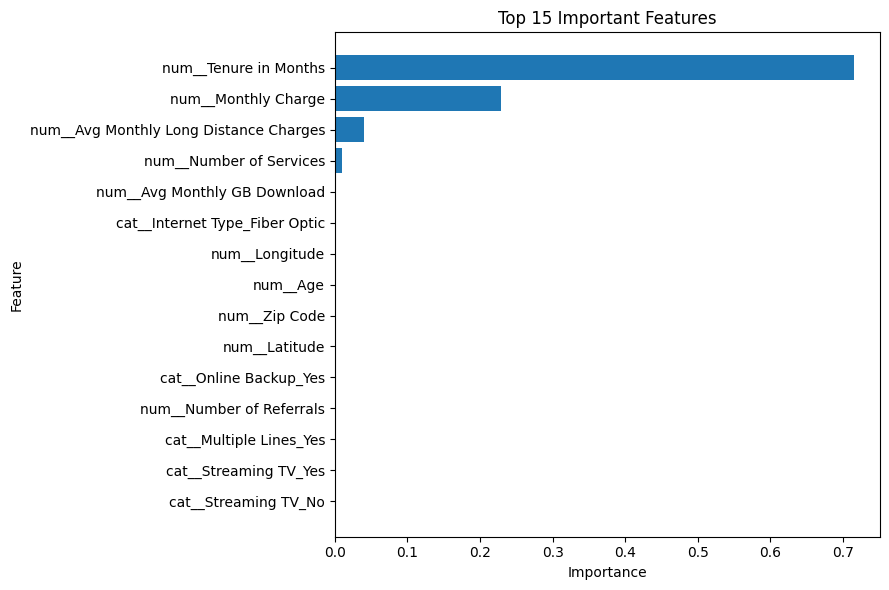

In [22]:
top15 = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(9,6))

plt.barh(

    top15["Feature"],
    top15["Importance"]

)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")

plt.tight_layout()

plt.show()

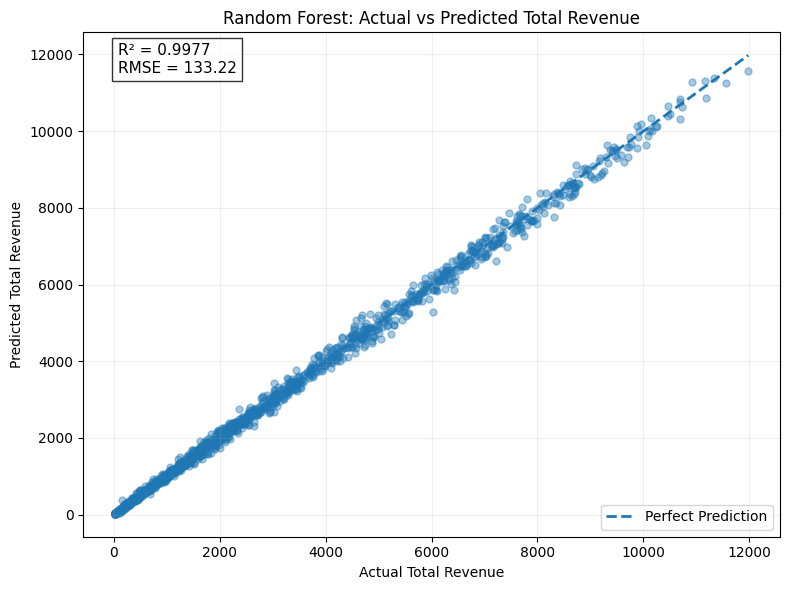

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.4,
    s=25
)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.text(
    0.05,
    0.92,
    f"R² = {rf_r2:.4f}\nRMSE = {rf_rmse:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.xlabel("Actual Total Revenue")
plt.ylabel("Predicted Total Revenue")

plt.title("Random Forest: Actual vs Predicted Total Revenue")

plt.legend()

plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()